# **Import libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math

In [2]:
sns.set_palette('viridis')

In [3]:
from sklearn import set_config
set_config(transform_output="pandas")

In [4]:
import warnings
warnings.filterwarnings("ignore")

# **Load Dataset**

[Dataset - Spaceship Titanic](https://www.kaggle.com/competitions/spaceship-titanic/data?select=train.csv)

In [5]:
df = pd.read_csv('train.csv')

# **Data Analysis**

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   object 
 1   HomePlanet    8492 non-null   object 
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   object 
 4   Destination   8511 non-null   object 
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   object 
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(7)
memory usage: 891.5+ KB


In [7]:
df.isna().sum()

,0
PassengerId,0
HomePlanet,201
CryoSleep,217
Cabin,199
Destination,182
Age,179
VIP,203
RoomService,181
FoodCourt,183
ShoppingMall,208


<Axes: >

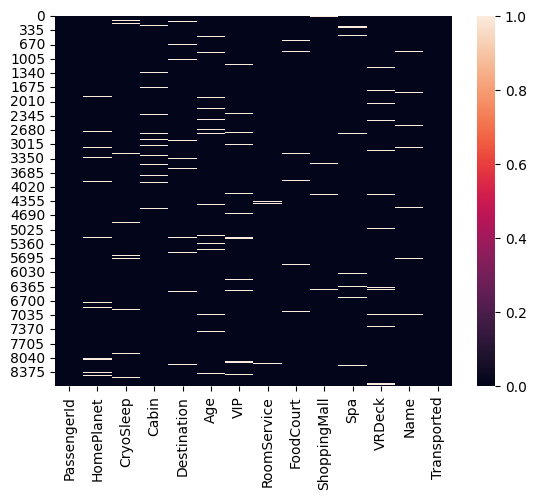

In [8]:
sns.heatmap(df.isna())

The data is missing randomly, no pattern is seen.

In [9]:
df.nunique()

,0
PassengerId,8693
HomePlanet,3
CryoSleep,2
Cabin,6560
Destination,3
Age,80
VIP,2
RoomService,1273
FoodCourt,1507
ShoppingMall,1115


There are several types of features:

- **categorical**: Name, Cabin, HomePlanet, Destination
- **continuous**: VRDeck, Spa, ShoppingMall, FoodCourt, RoomService, Age
- **binary**: CryoSleep, VIP, Transported

In [10]:
df.describe()

,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
count,8514.000000,8512.000000,8510.000000,8485.000000,8510.000000,8505.000000
mean,28.827930,224.687617,458.077203,173.729169,311.138778,304.854791
std,14.489021,666.717663,1611.489240,604.696458,1136.705535,1145.717189
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,19.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,38.000000,47.000000,76.000000,27.000000,59.000000,46.000000
max,79.000000,14327.000000,29813.000000,23492.000000,22408.000000,24133.000000


In this spaceship are all categories of people - newborns(0 years), young, and elders. However, the majority are young - 3 quarters are equal or less than 38 years.

The larger number of people hadn't paid for any services - more than 50%. However, the largest amount spent is almost 30k.

In [11]:
num_cols = df.select_dtypes(include='number').columns.tolist()

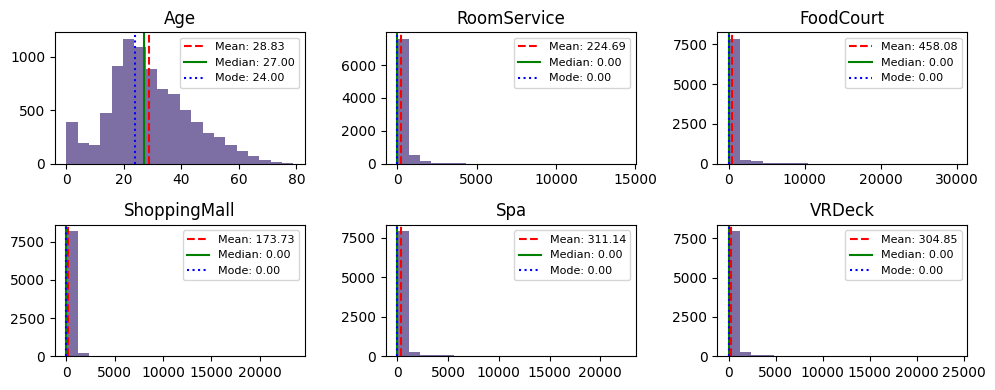

In [12]:
n_cols = 3
n_rows = int(np.ceil(len(num_cols) / n_cols))

fig, axs = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(10, 4))
axs = axs.flatten()

for col, ax in zip(num_cols, axs):
    data = df[col].dropna()

    ax.hist(data, bins=20, alpha=0.7)

    mean = data.mean()
    median = data.median()
    mode = data.mode()
    if len(mode) > 0:
        mode = mode.iloc[0]
    else:
        mode = np.nan

    ax.axvline(mean, color='red', linestyle='dashed', linewidth=1.5, label=f'Mean: {mean:.2f}')
    ax.axvline(median, color='green', linestyle='solid', linewidth=1.5, label=f'Median: {median:.2f}')
    ax.axvline(mode, color='blue', linestyle='dotted', linewidth=1.5, label=f'Mode: {mode:.2f}')

    ax.set_title(col)
    ax.legend(fontsize=8)

for ax in axs[len(num_cols):]:
    ax.axis('off')

plt.tight_layout()
plt.show()

For services - the same thing we noticed earlier.

The age median, mean, and mode are pretty close, as well as the data looks quite bell-shaped, even though it is right-skewed.

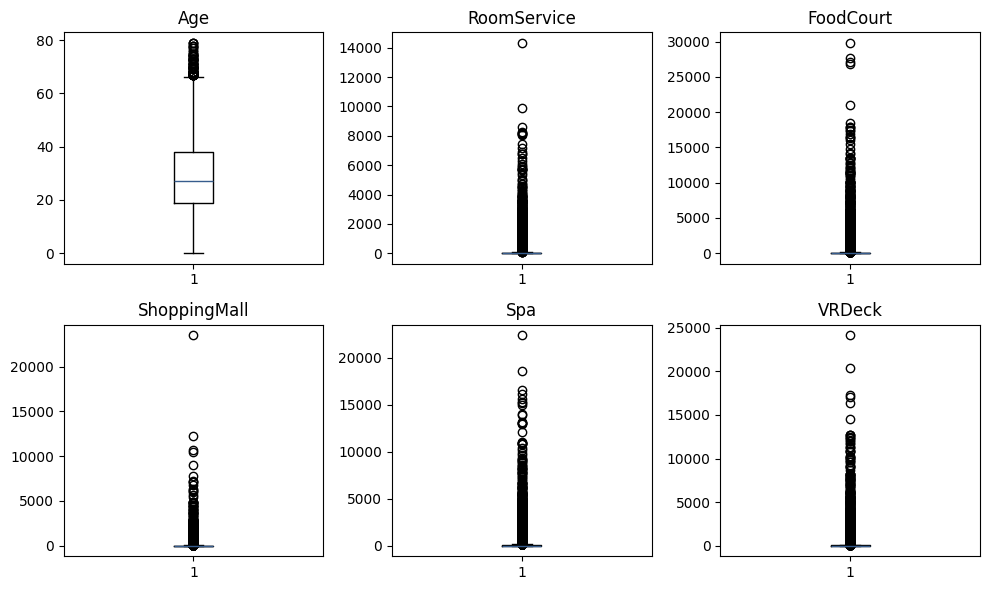

In [13]:
n_cols = 3
n_rows = int(np.ceil(len(num_cols) / n_cols))

fig, axs = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(10, 6))
axs = axs.flatten()

for col, ax in zip(num_cols, axs):
    data = df[col].dropna()

    ax.boxplot(data)

    ax.set_title(col)

for ax in axs[len(num_cols):]:
    ax.axis('off')

plt.tight_layout()
plt.show()

As mentioned earlier, the majority of people hadn't used services at all.  So, almost any person who has used services is viewed as an outlier.

Usually, people were aged 0-67, however some older people also were present. A typical pasanger was 27 years old.

In [14]:
df.duplicated().sum()

np.int64(0)

In [15]:
cat_cols = df.select_dtypes(exclude='number').columns.tolist()
[cat_cols.remove(e) for e in ['PassengerId','Cabin', 'Name']]

[None, None, None]

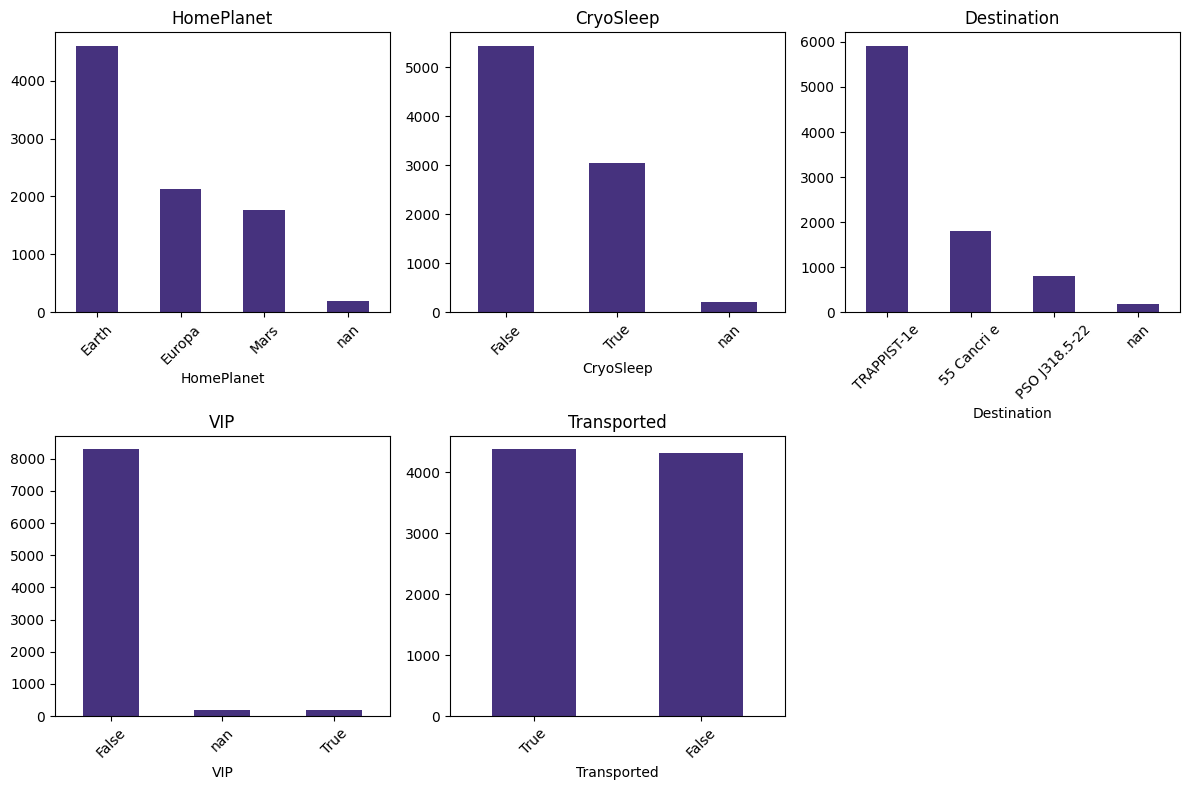

In [16]:
ncols = 3
nrows = math.ceil(len(cat_cols) / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
  df[col].value_counts(dropna=False).plot.bar(ax=axes[i])
  axes[i].set_title(col)
  axes[i].tick_params(axis='x', rotation=45)

[fig.delaxes(axes[j]) for j in range(i + 1, len(axes))]

plt.tight_layout()
plt.show()

Many of the people weren't VIP, The most popular Home Planet was Earth, while the most popular destination was TRAPPIST-1e.

An equal number of people were and weren't transported to the destination.

In [17]:
df['Transported'] = df['Transported'].astype(int)

In [18]:
corr_matrix = df.dropna()[df.select_dtypes(include='number').columns].corr()

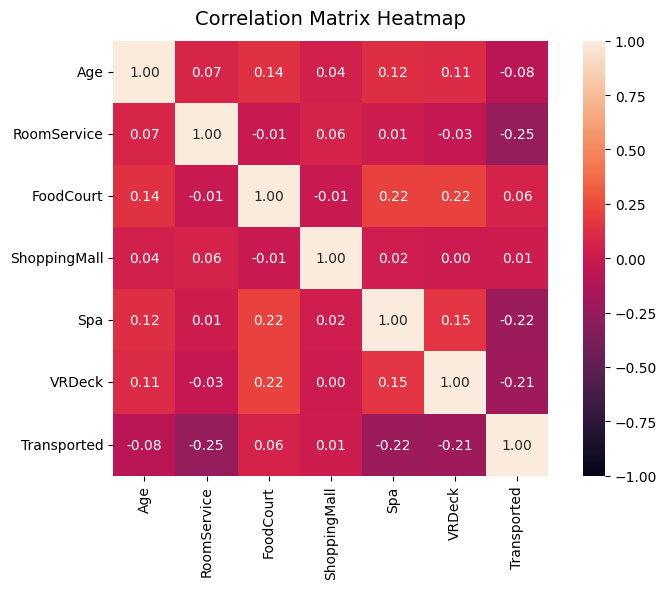

In [19]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    corr_matrix,
    annot=True,
    vmin=-1,
    vmax=1,
    fmt=".2f",
    square=True
)

plt.title('Correlation Matrix Heatmap', fontsize=14, pad=12)
plt.tight_layout()
plt.show()

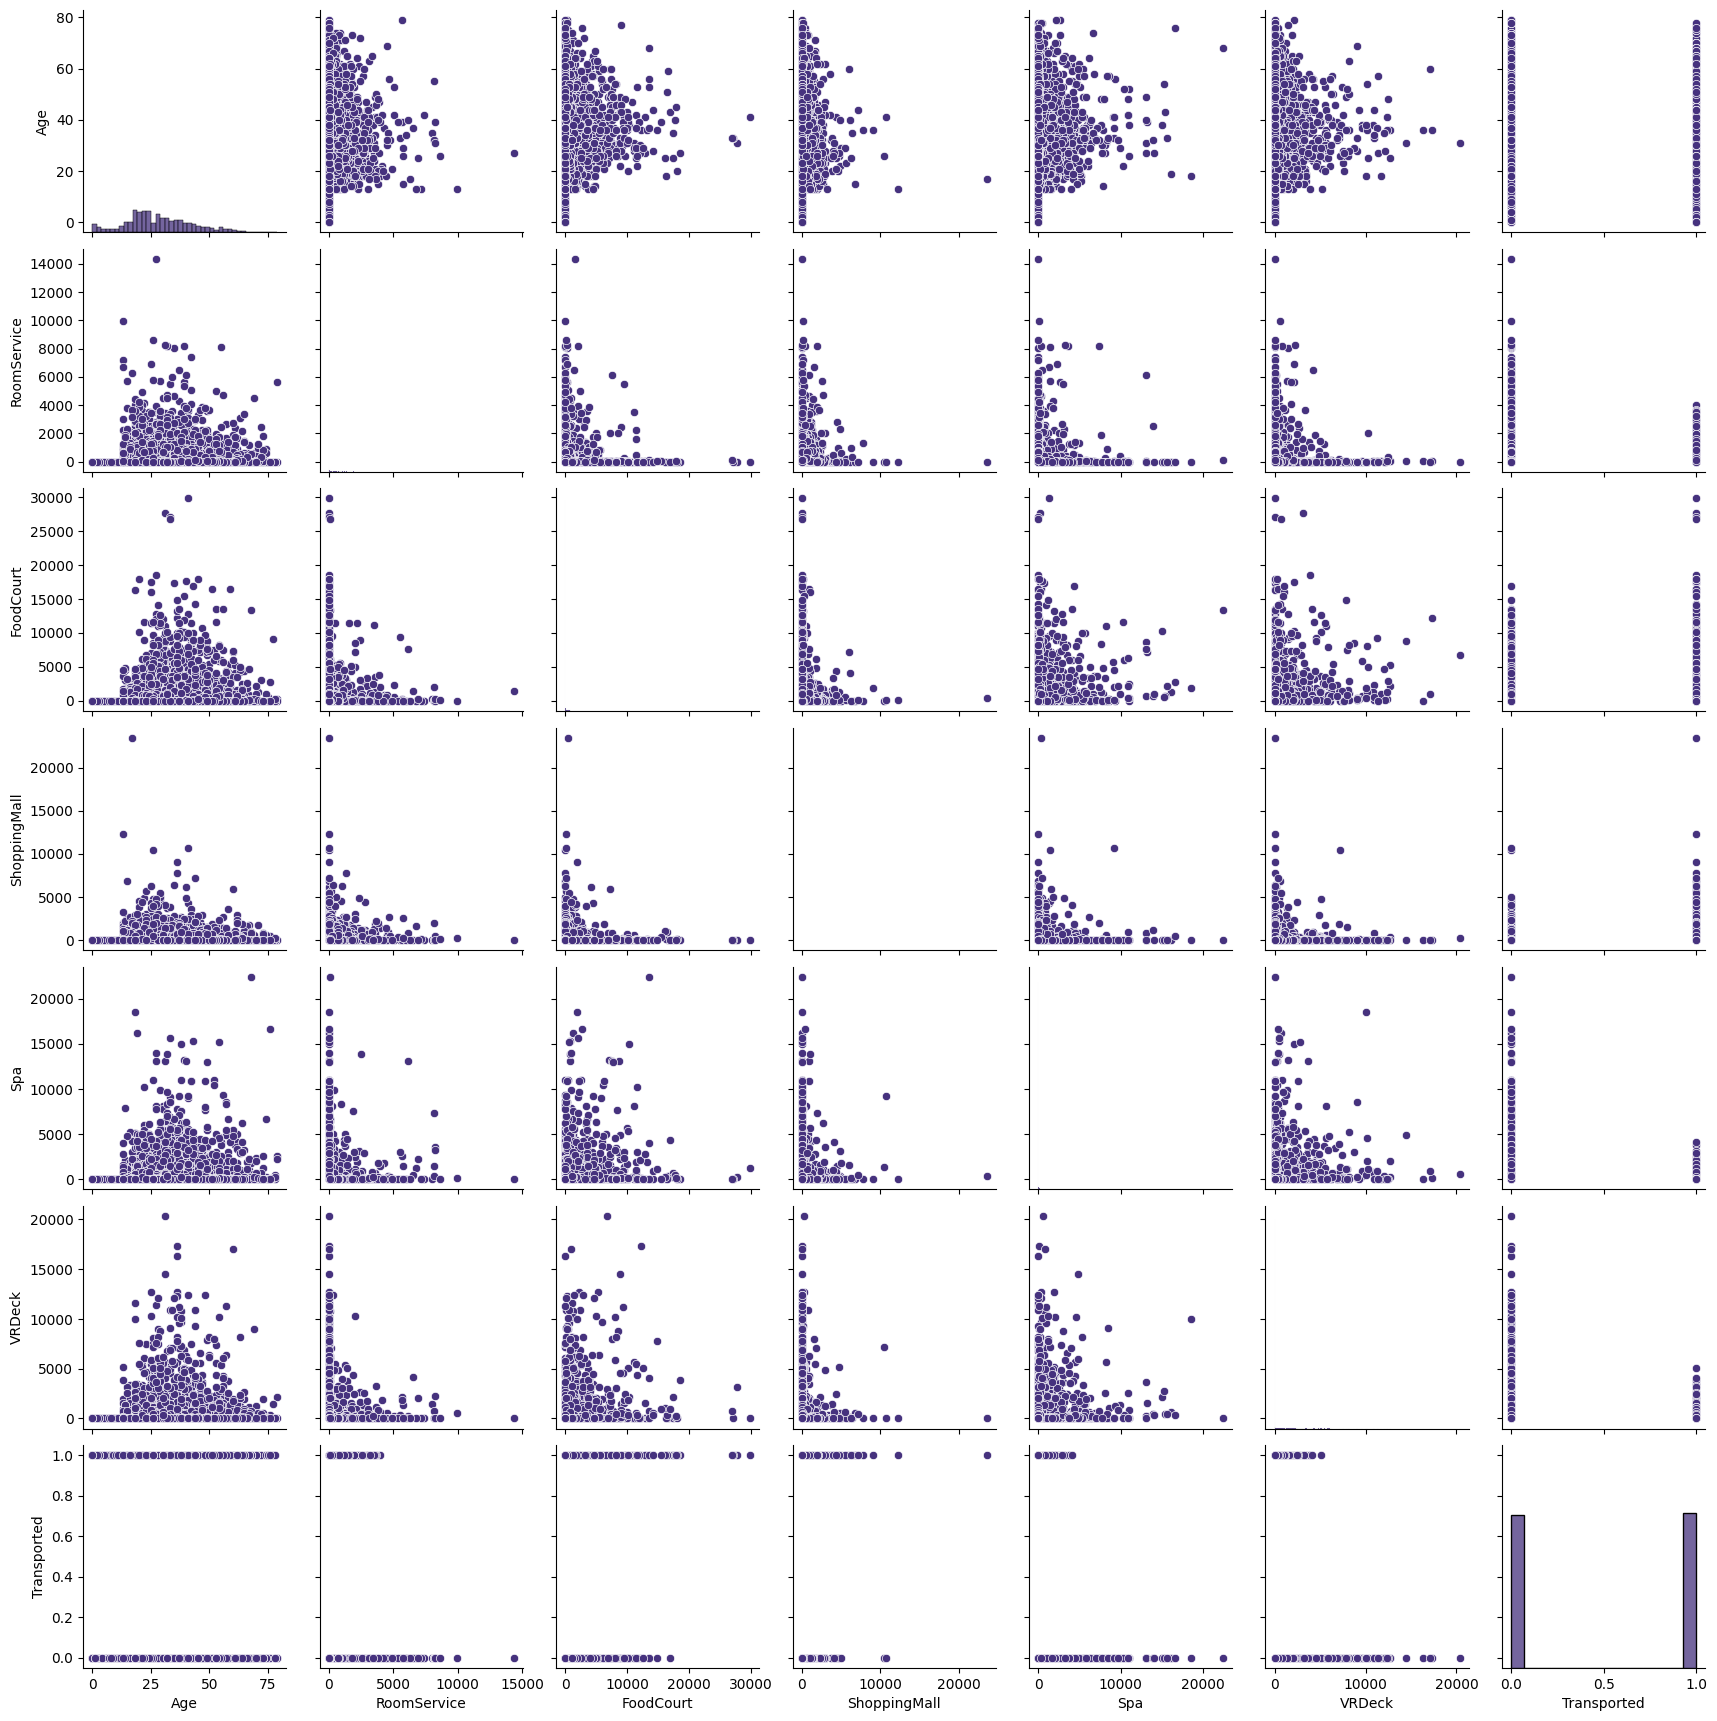

In [20]:
num_df = df.select_dtypes(include="number").dropna()

sns.pairplot(num_df)

In [21]:
df.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,0
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,1
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,0
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,0
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,1


In [22]:
corr = df[df.select_dtypes(include='number').columns].corr()

In [23]:
pd.DataFrame(np.abs(corr)).sort_values('Transported', ascending=False)['Transported'].head()

,Transported
Transported,1.000000
RoomService,0.244611
Spa,0.221131
VRDeck,0.207075
Age,0.075026


# **Data Preprocessing**

## **Feature Engineering**

In [24]:
df["CryoSleep"] = df["CryoSleep"].astype('Int64')
df["VIP"] = df["VIP"].astype('Int64')

In [25]:
split = df["PassengerId"].str.split("_", expand=True)

df["Group"] = split[0].astype(int)
df["Id"] = split[1].astype(int)

In [26]:
df["CabinMissing"] = df["Cabin"].isna().astype(int)

In [27]:
split = df["Cabin"].str.split("/", expand=True)

df["Deck"] = split[0]
df["CabinNumber"] = split[1].astype('Int64')
df["Side"] = split[2]

In [28]:
split = df["Name"].str.split(" ", expand=True)

split.nunique()

,0
0,2706
1,2217


In [29]:
df['FamilyName'] = split[1]

In [30]:
df.drop(['Cabin', 'PassengerId', 'Name'], axis=1, inplace=True)

In [31]:
df["HomePlanetMissing"] = df["HomePlanet"].isna().astype(int)
df["DestinationMissing"] = df["Destination"].isna().astype(int)

## **Encoding 1**

In [32]:
df = pd.get_dummies(
    df,
    columns=["HomePlanet", "Destination"],
    dtype=int
)

In [33]:
df["Side"] = df["Side"].map({"P": 0, "S": 1}).astype('Int64')

## **Splitting**

In [34]:
from sklearn.model_selection import train_test_split, StratifiedKFold

In [35]:
X = df.drop('Transported', axis=1)
y = df['Transported']

In [36]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [37]:
X_trains, X_tests, y_trains, y_tests = [], [], [], []

for train_idx, test_idx in cv.split(X, y):
    X_trains.append(X.iloc[train_idx].copy())
    X_tests.append(X.iloc[test_idx].copy())
    y_trains.append(y.iloc[train_idx].copy())
    y_tests.append(y.iloc[test_idx].copy())

## **Encoding 2**

In [38]:
from sklearn.preprocessing import TargetEncoder

In [39]:
pd.concat([df.nunique(), df.dtypes], axis=1)

,0,1
CryoSleep,2,Int64
Age,80,float64
VIP,2,Int64
RoomService,1273,float64
FoodCourt,1507,float64
ShoppingMall,1115,float64
Spa,1327,float64
VRDeck,1306,float64
Transported,2,int64
Group,6217,int64


In [40]:
tg_enc_cols = [
    'Deck',
    'FamilyName',
    'Group',
    'CabinNumber'
]

In [41]:
for (X_train, y_train, X_test) in zip(X_trains, y_trains, X_tests):
  tg_enc = TargetEncoder()
  X_train[tg_enc_cols] = tg_enc.fit_transform(X_train[tg_enc_cols], y_train)
  X_test[tg_enc_cols] = tg_enc.transform(X_test[tg_enc_cols])

## **Models**

In [42]:
!pip install xgboost

In [43]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
import xgboost as xgb

In [44]:
from sklearn.metrics import f1_score, accuracy_score, recall_score, precision_score, roc_auc_score

In [45]:
from sklearn.pipeline import Pipeline
from sklearn.base import clone

In [46]:
models = [
    LogisticRegression(random_state=42),
    RandomForestClassifier(n_estimators=200, random_state=42),
    SVC(kernel='poly', random_state=42),
    SVC(kernel='rbf', random_state=42),
    GaussianNB(),
    KNeighborsClassifier(),
    xgb.XGBClassifier()
]

In [47]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [48]:
def plot_conf_matrix(y_tests, y_preds, title, labels):
  fig, axs = plt.subplots(ncols=len(y_tests), figsize=(15, 15))

  for i, (y_test, y_pred) in enumerate(zip(y_tests, y_preds)):
      cm = confusion_matrix(y_test, y_pred)
      disp = ConfusionMatrixDisplay(
          confusion_matrix=cm,
          display_labels=labels
      )
      disp.plot(ax=axs[i], colorbar=False)

  plt.title(title)
  plt.tight_layout()

## **Data Imputation**

In [49]:
from sklearn.impute import KNNImputer
from sklearn.impute import SimpleImputer

In [50]:
missing_vals_cols = [
  'CryoSleep',
  'Age',
  'VIP',
  'RoomService',
  'FoodCourt',
  'ShoppingMall',
  'Spa',
  'VRDeck',
  'CabinNumber',
  'Side'
]

In [51]:
df.isna().sum()

,0
CryoSleep,217
Age,179
VIP,203
RoomService,181
FoodCourt,183
ShoppingMall,208
Spa,183
VRDeck,188
Transported,0
Group,0


In [52]:
all_cols = df.drop('Transported', axis=1).columns

In [53]:
from sklearn.compose import ColumnTransformer

In [54]:
preps = [
    ('knn_imputer',KNNImputer(n_neighbors=5)),
    ('median_imputer',SimpleImputer(strategy='most_frequent'))
]

preprocessors = [
  ColumnTransformer(
    transformers=[(i, j, missing_vals_cols)],
    remainder="passthrough",
    verbose_feature_names_out=False
) for (i,j) in preps]

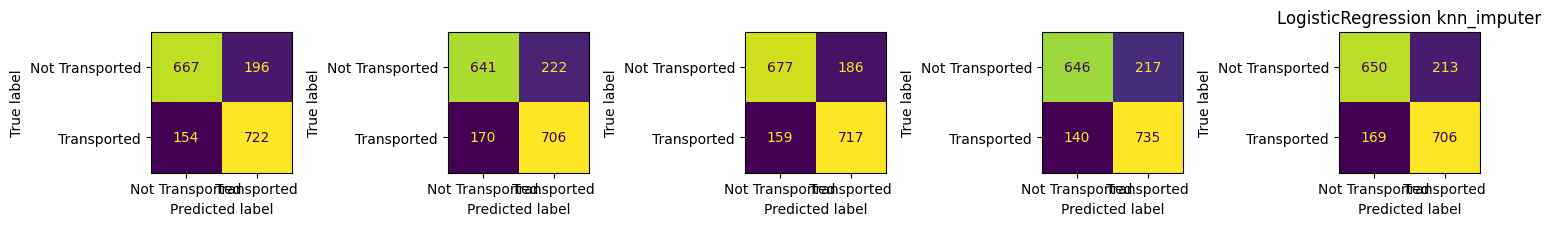

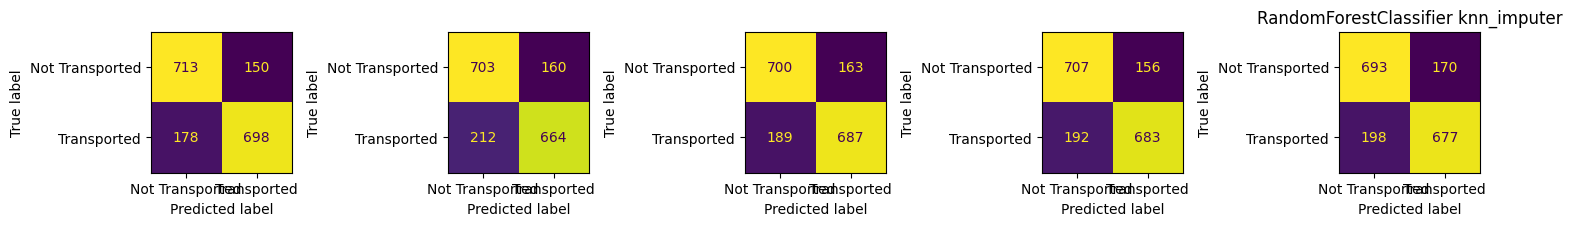

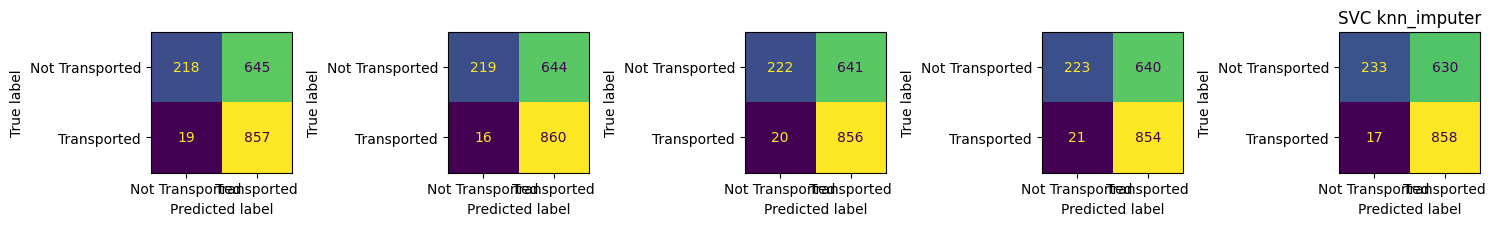

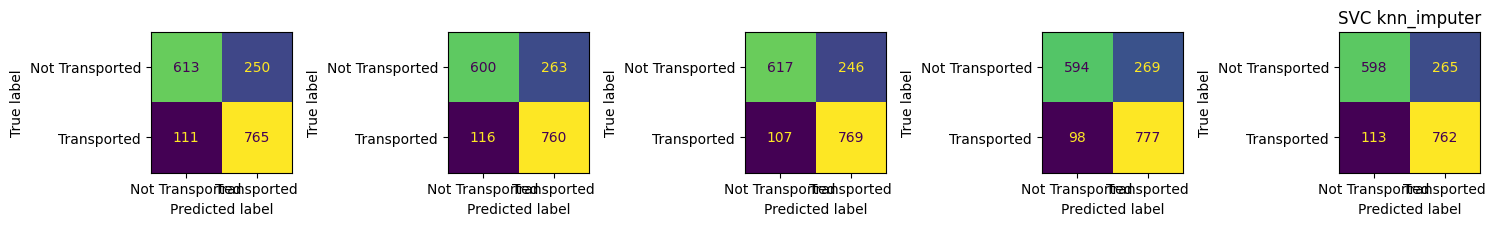

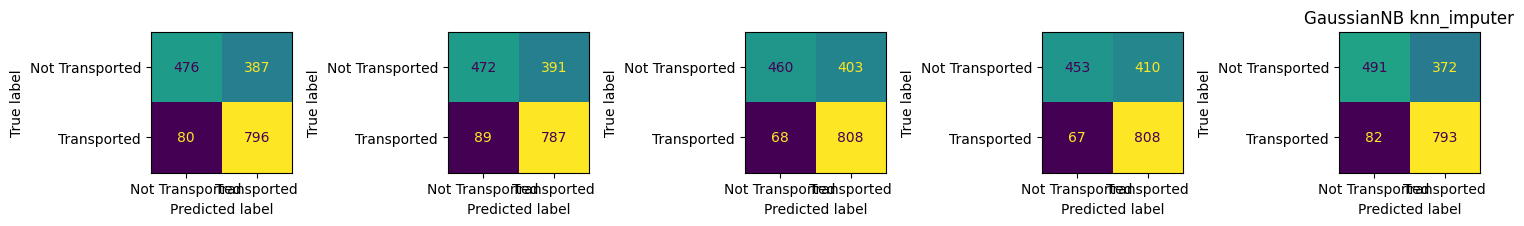

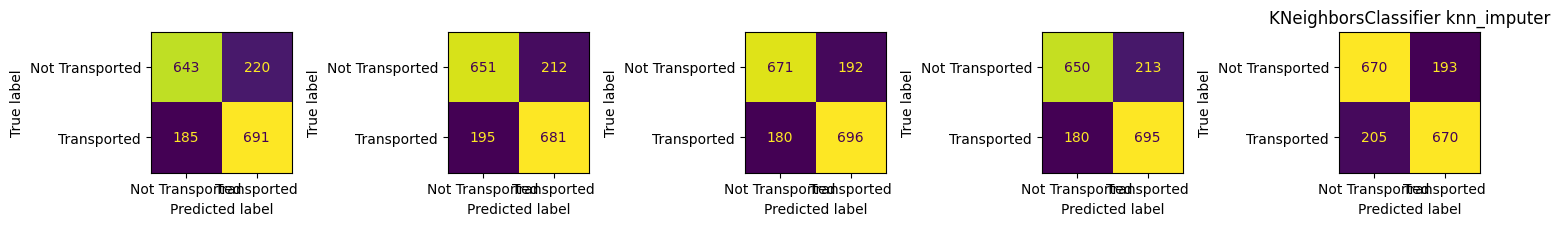

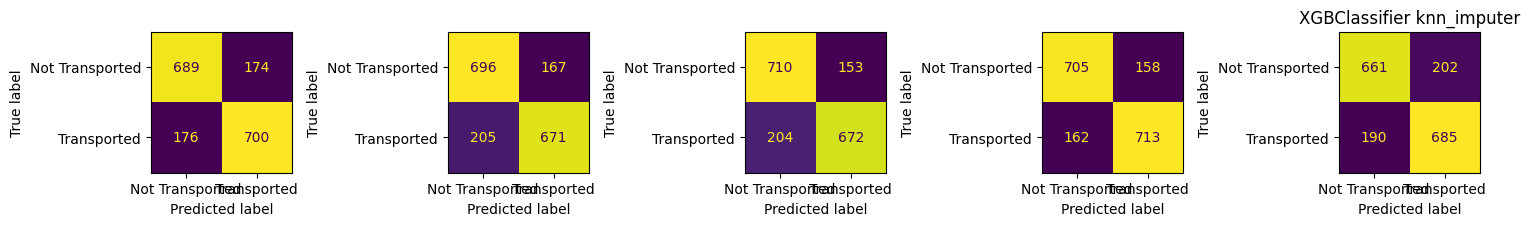

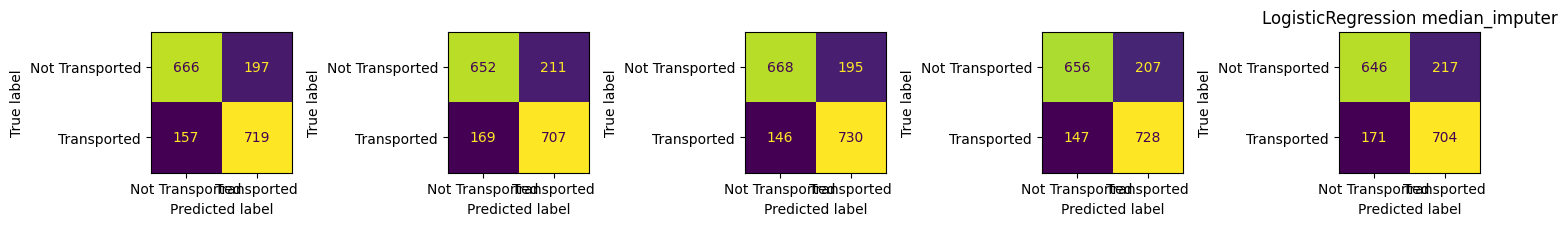

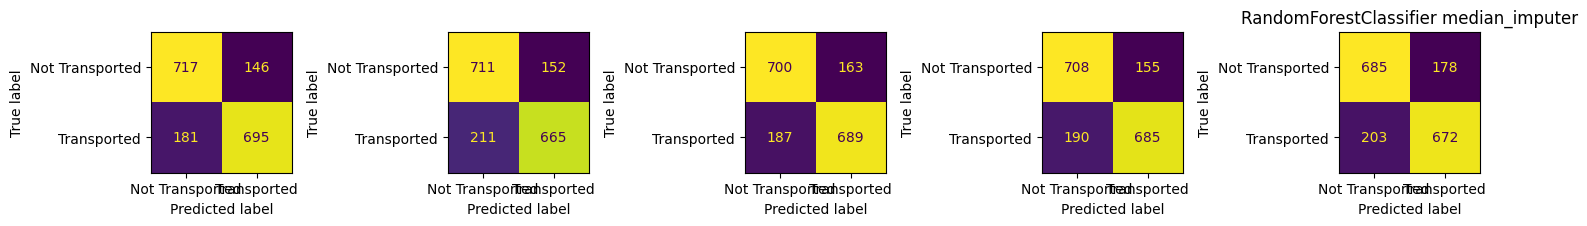

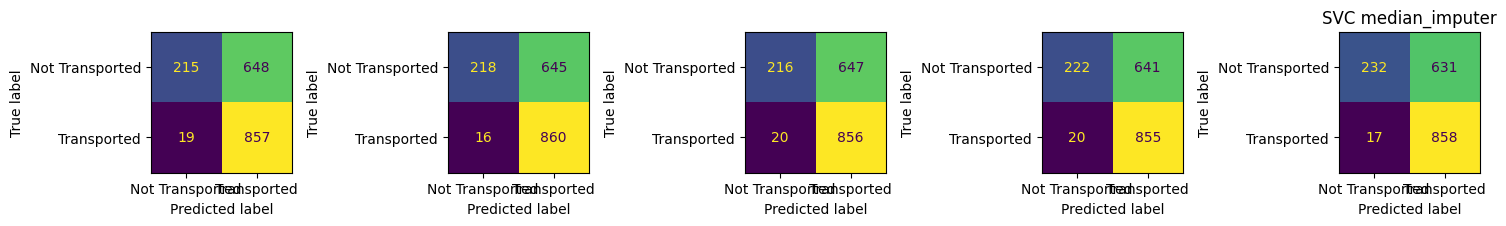

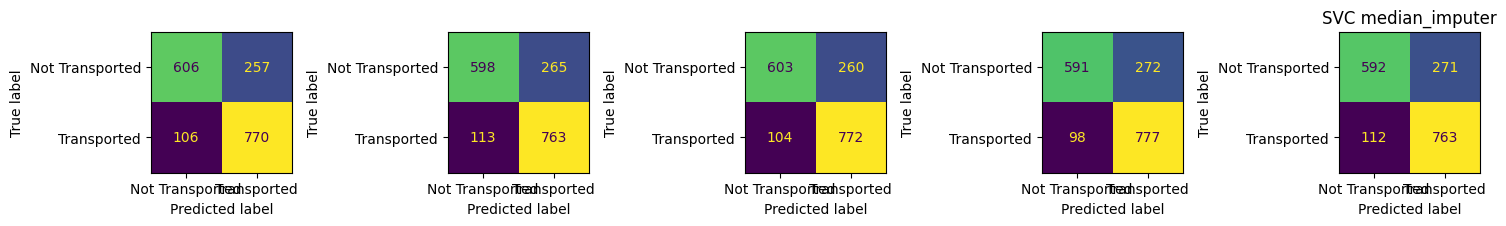

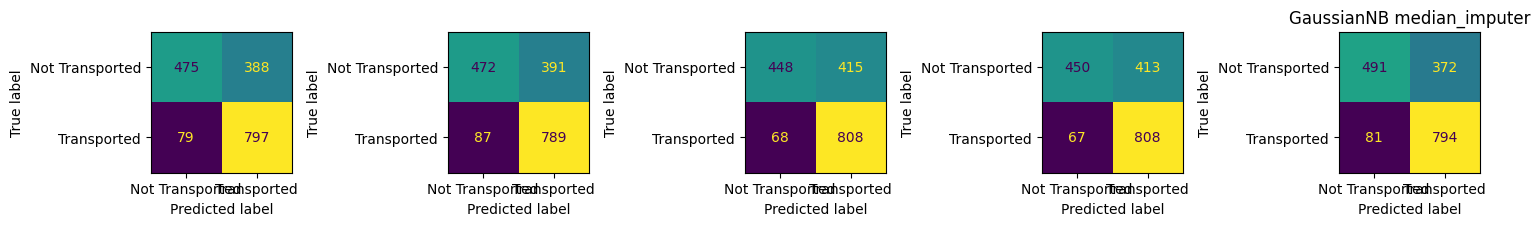

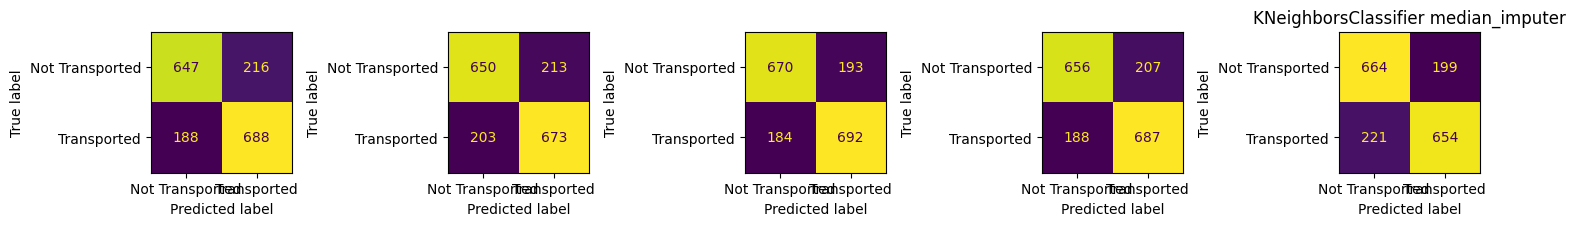

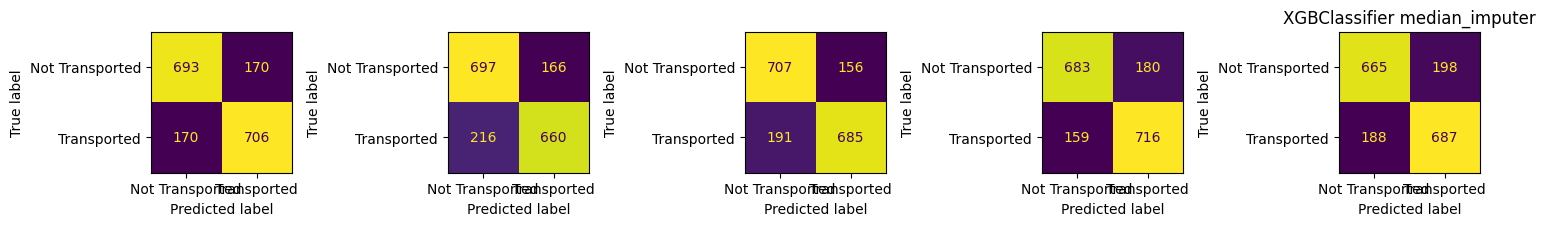

In [55]:
scores = []

for preprocessor in preprocessors:
  for model in models:
    pipeline = Pipeline([
        ("preprocessor", clone(preprocessor)),
        ("model", clone(model)),
    ])

    accuracy = []
    f1 = []
    recall = []
    precision = []
    roc_auc = []

    y_preds = []

    for X_train, y_train, X_test, y_test in zip(X_trains, y_trains, X_tests, y_tests):
      pipeline.fit(X_train, y_train)

      y_pred = pipeline.predict(X_test)
      y_preds.append(y_pred)

      accuracy.append(accuracy_score(y_test, y_pred))
      f1.append(f1_score(y_test, y_pred))
      recall.append(recall_score(y_test, y_pred))
      precision.append(precision_score(y_test, y_pred))
      roc_auc.append(roc_auc_score(y_test, y_pred))

    model_name = type(model).__name__
    prep_name = preprocessor.transformers[0][0]

    plot_conf_matrix(y_tests, y_preds, f'{model_name} {prep_name}',
                     ['Not Transported', 'Transported'])

    scores.append({
    "model": model_name,
    "preprocessor": prep_name,
    "accuracy": np.mean(accuracy),
    "f1": np.mean(f1),
    "recall": np.mean(recall),
    "precision": np.mean(precision),
    "roc_auc": np.mean(roc_auc),
    })

In [56]:
pd.DataFrame(scores)

,model,preprocessor,accuracy,f1,recall,precision,roc_auc
0,LogisticRegression,knn_imputer,0.789945,0.797069,0.819097,0.776315,0.789734
1,RandomForestClassifier,knn_imputer,0.796617,0.794049,0.778665,0.810106,0.796749
2,SVC,knn_imputer,0.621190,0.722417,0.978757,0.572485,0.618579
3,SVC,knn_imputer,0.788565,0.806612,0.875516,0.747808,0.787932
4,GaussianNB,knn_imputer,0.729783,0.772673,0.911833,0.670447,0.728454
5,KNeighborsClassifier,knn_imputer,0.772806,0.776598,0.784146,0.769334,0.772722
6,XGBClassifier,knn_imputer,0.793972,0.793467,0.785981,0.801408,0.794033
7,LogisticRegression,median_imputer,0.790980,0.797937,0.819552,0.777454,0.790772
8,RandomForestClassifier,median_imputer,0.796847,0.794111,0.777980,0.811020,0.796985
9,SVC,median_imputer,0.619925,0.721797,0.978986,0.571628,0.617303


Looking at the results for both of the imputers, they practically have the same effect on the models' performance. However, having the first slightly outperforming 4 out of 6, we'll go with the first one - KNNImputer.

Also, SVC with poly kernel has the lowest score, so it will be dropped. Also, Gaussian Naive Bayes is not as good as others - drop it.

In [57]:
models.pop(4)
models.pop(2)

SVC(kernel='poly', random_state=42)

In [58]:
for X_train, y_train, X_test in zip(X_trains, y_trains, X_tests):
  knn_imputer = KNNImputer()
  X_train[missing_vals_cols] = knn_imputer.fit_transform(X_train[missing_vals_cols], y_train)
  X_test[missing_vals_cols] = knn_imputer.transform(X_test[missing_vals_cols])

### Check correlation one more time

In [59]:
corr_matrix = pd.concat([X_trains[0],y_trains[0]],axis=1).corr()

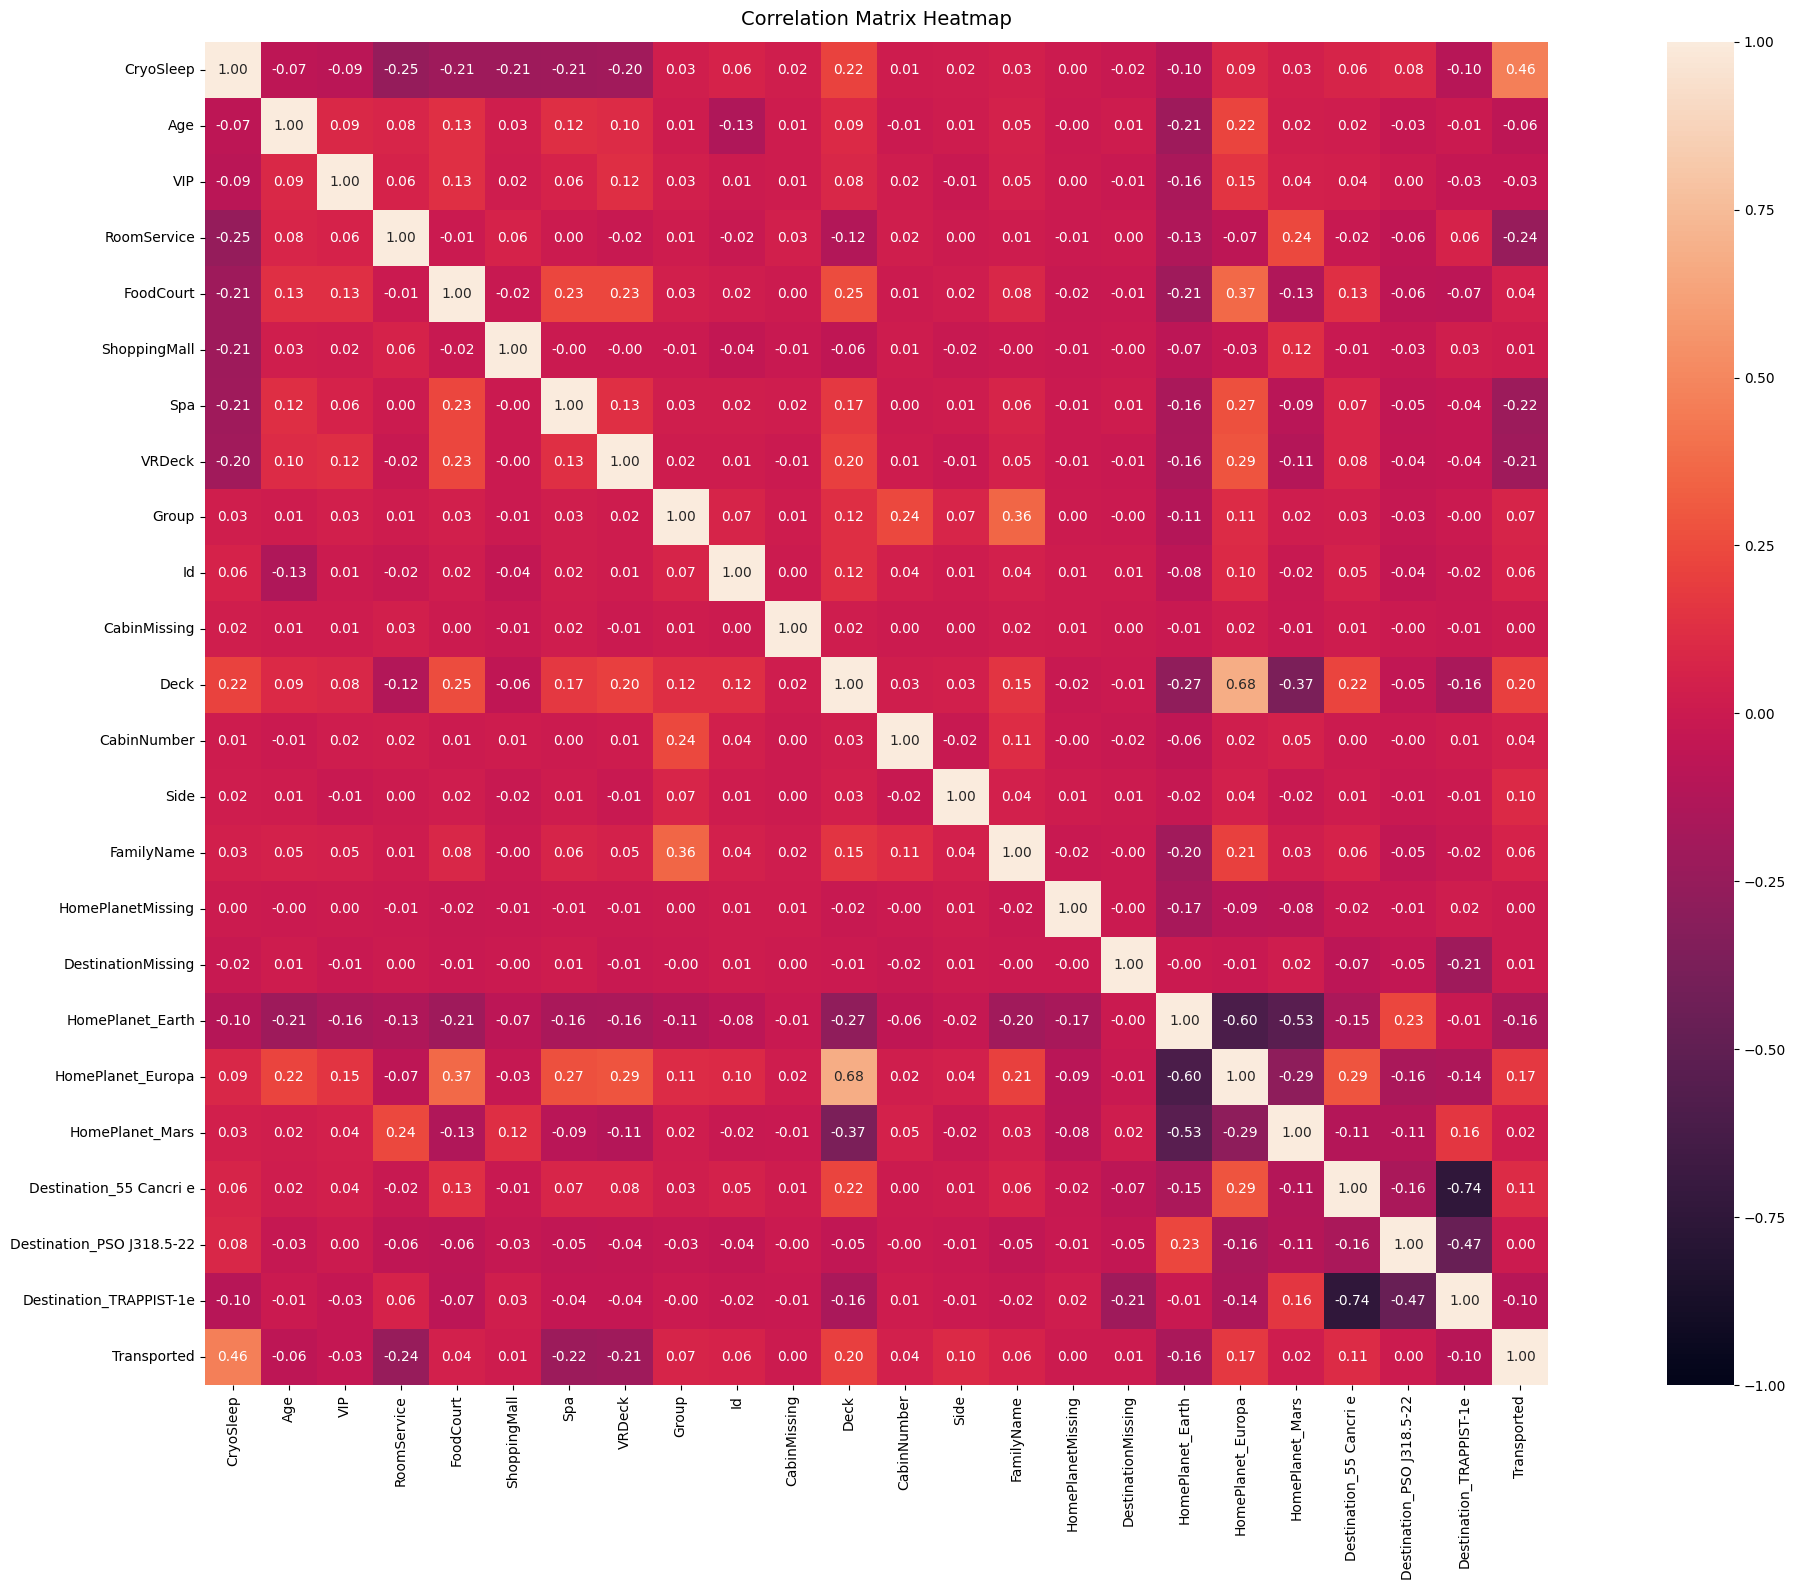

In [60]:
plt.figure(figsize=(24, 16))

sns.heatmap(
    corr_matrix,
    annot=True,
    vmin=-1,
    vmax=1,
    fmt=".2f",
    square=True
)

plt.title('Correlation Matrix Heatmap', fontsize=14, pad=12)
plt.tight_layout()
plt.show()

## **Feature Scaling**

In [61]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

In [62]:
cols_out = ['Age', 'VIP', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']

In [63]:
scalers = [
    ColumnTransformer(transformers = [
        ('std_scaler', StandardScaler(),
         lambda X: [c for c in cols_out if c in X.columns])
        ], remainder="passthrough",
        verbose_feature_names_out=False),
    ColumnTransformer(transformers = [
        ('mm_scaler', MinMaxScaler(),
         lambda X: [c for c in cols_out if c in X.columns])
        ], remainder="passthrough",
        verbose_feature_names_out=False)
]

In [64]:
scores = []

for scaler in scalers:
  for model in models:
    pipeline = Pipeline([
        ("scaler", clone(scaler)),
        ("model", clone(model)),
    ])

    accuracy = []
    f1 = []
    recall = []
    precision = []
    roc_auc = []

    for X_train, y_train, X_test, y_test in zip(X_trains, y_trains, X_tests, y_tests):
      pipeline.fit(X_train, y_train)

      y_pred = pipeline.predict(X_test)

      accuracy.append(accuracy_score(y_test, y_pred))
      f1.append(f1_score(y_test, y_pred))
      recall.append(recall_score(y_test, y_pred))
      precision.append(precision_score(y_test, y_pred))
      roc_auc.append(roc_auc_score(y_test, y_pred))

    scores.append({
    "model": type(model).__name__,
    "scaler": scaler.transformers[0][0],
    "accuracy": np.mean(accuracy),
    "f1": np.mean(f1),
    "recall": np.mean(recall),
    "precision": np.mean(precision),
    "roc_auc": np.mean(roc_auc),
    })

In [65]:
pd.DataFrame(scores)

,model,scaler,accuracy,f1,recall,precision,roc_auc
0,LogisticRegression,std_scaler,0.794546,0.800577,0.818867,0.783174,0.794370
1,RandomForestClassifier,std_scaler,0.795812,0.793109,0.777294,0.809614,0.795947
2,SVC,std_scaler,0.794086,0.797864,0.807217,0.788852,0.793991
3,KNeighborsClassifier,std_scaler,0.759231,0.761488,0.763133,0.759876,0.759203
4,XGBClassifier,std_scaler,0.793857,0.793280,0.785524,0.801486,0.793921
5,LogisticRegression,mm_scaler,0.767629,0.757517,0.720879,0.798182,0.767971
6,RandomForestClassifier,mm_scaler,0.794661,0.791904,0.775924,0.808586,0.794799
7,SVC,mm_scaler,0.750718,0.726781,0.658290,0.811241,0.751393
8,KNeighborsClassifier,mm_scaler,0.698264,0.689430,0.664916,0.715865,0.698507
9,XGBClassifier,mm_scaler,0.793857,0.793280,0.785524,0.801486,0.793921


Standard Scaler has proven to have better results than MinMax Scaler.

In [66]:
for X_train, y_train, X_test in zip(X_trains, y_trains, X_tests):
  std_scaler = StandardScaler()
  X_train[cols_out] = std_scaler.fit_transform(X_train[cols_out], y_train)
  X_test[cols_out] = std_scaler.transform(X_test[cols_out])

### Check correlation one more time

In [67]:
corr_matrix = pd.concat([X_trains[0],y_trains[0]],axis=1).corr()

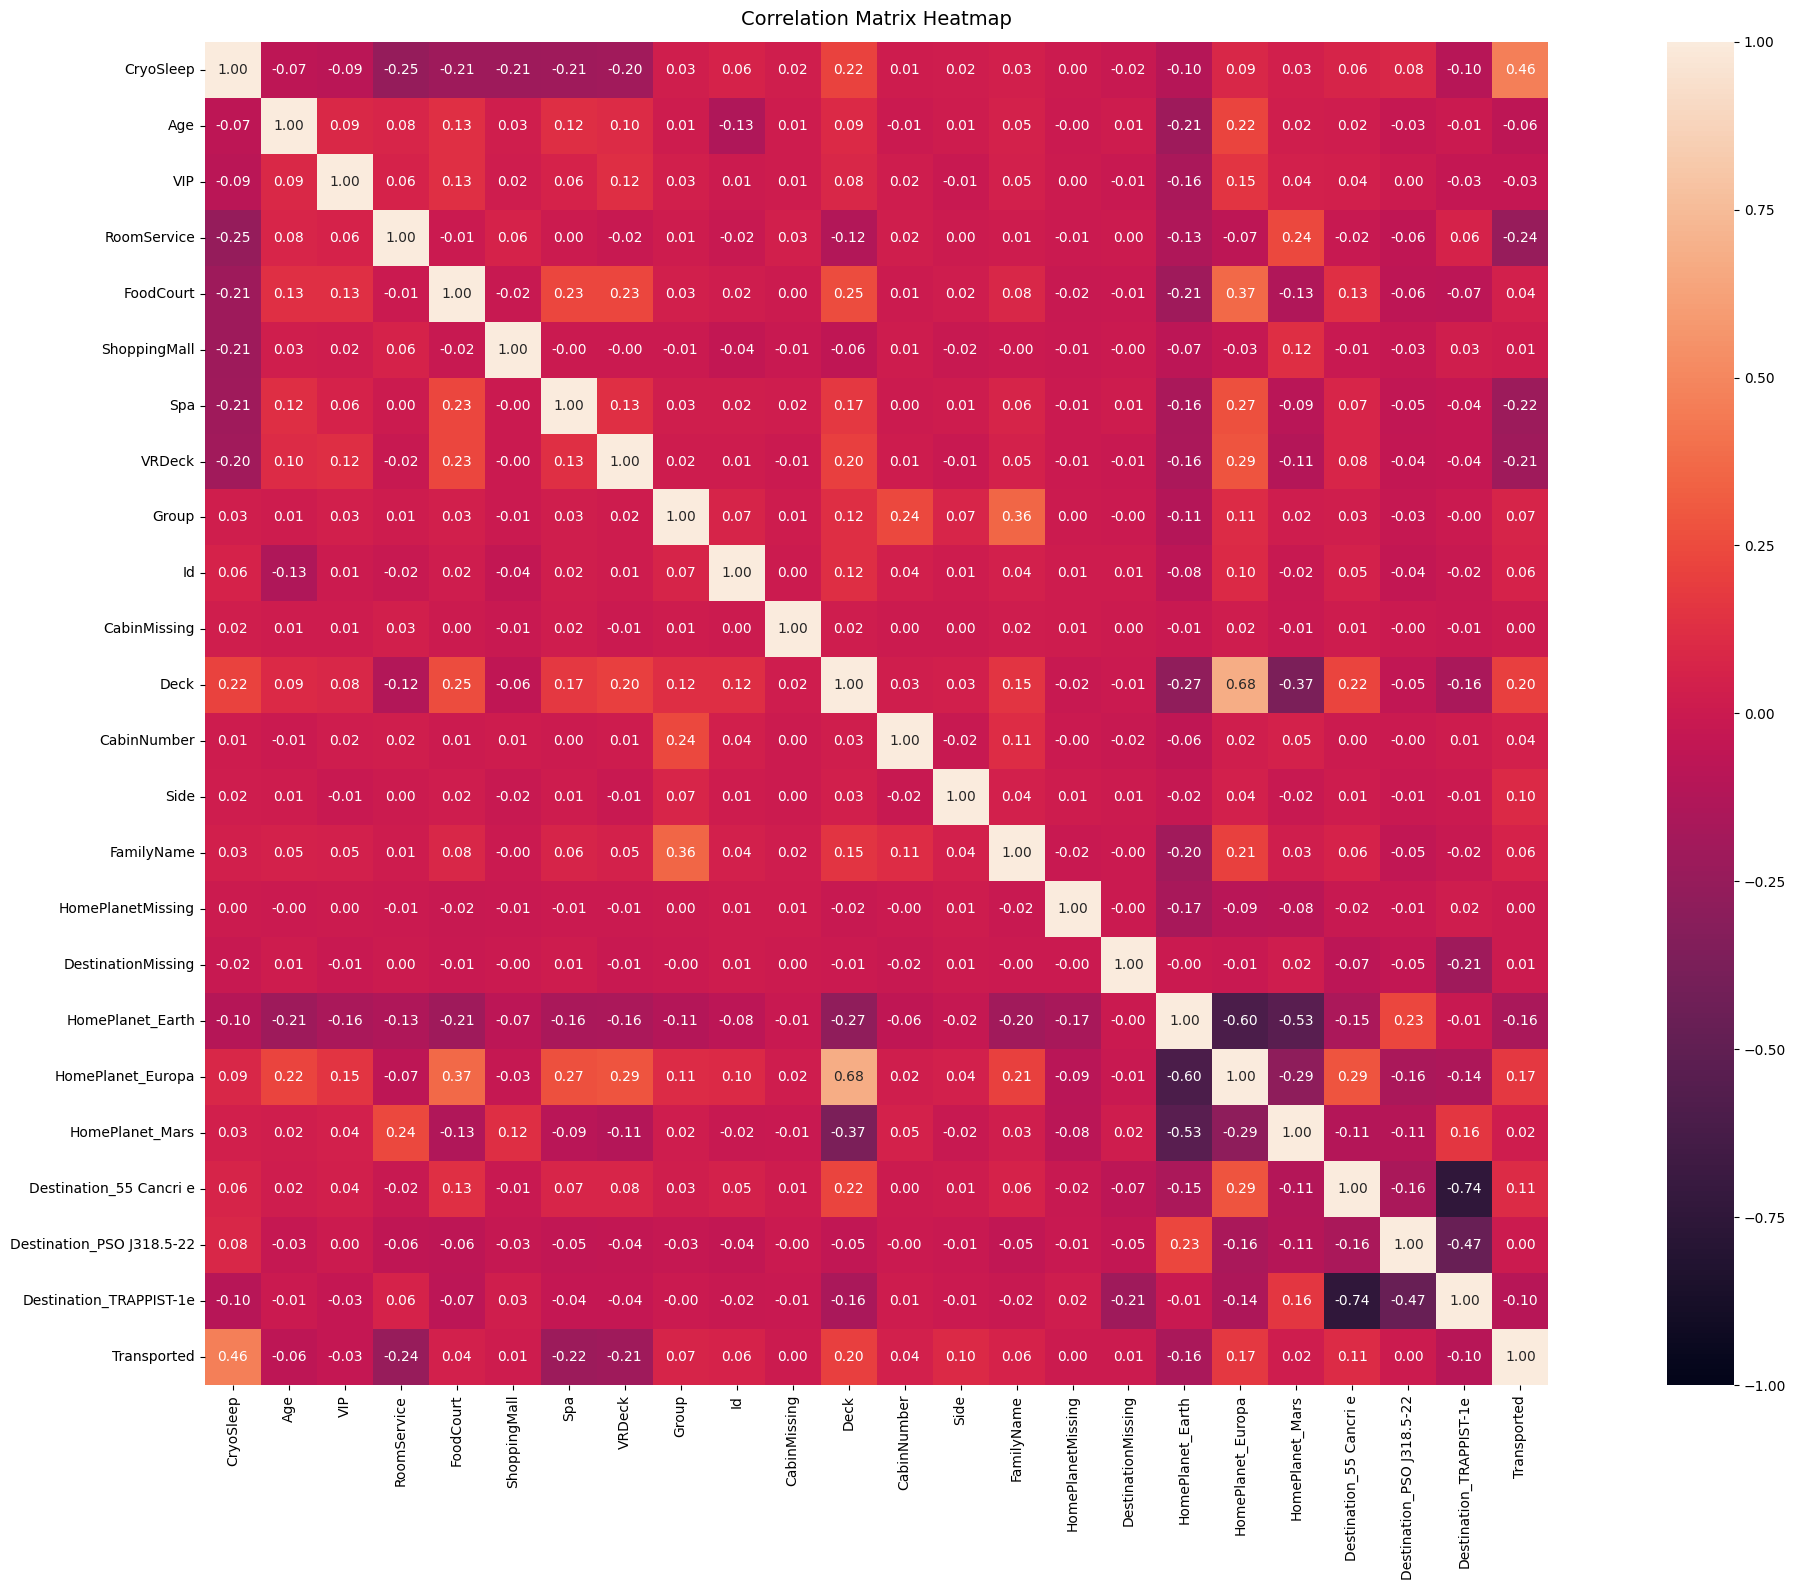

In [68]:
plt.figure(figsize=(24, 16))

sns.heatmap(
    corr_matrix,
    annot=True,
    vmin=-1,
    vmax=1,
    fmt=".2f",
    square=True
)

plt.title('Correlation Matrix Heatmap', fontsize=14, pad=12)
plt.tight_layout()
plt.show()

## **Outlier detection**

In [69]:
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM

In [70]:
detectors = [
    ('isolation_forest', IsolationForest()),
    ('local_outlier_factor', LocalOutlierFactor()),
    ('one_class_SVM', OneClassSVM()),
]

In [71]:
scores = []

for detector in detectors:
  for model in models:
    out_detector = clone(detector[1])

    accuracy = []
    f1 = []
    recall = []
    precision = []
    roc_auc = []

    for X_train, y_train, X_test, y_test in zip(X_trains, y_trains, X_tests, y_tests):
      mask = out_detector.fit_predict(X_train) == 1

      model.fit(X_train[mask], y_train[mask])

      y_pred = model.predict(X_test)

      accuracy.append(accuracy_score(y_test, y_pred))
      f1.append(f1_score(y_test, y_pred))
      recall.append(recall_score(y_test, y_pred))
      precision.append(precision_score(y_test, y_pred))
      roc_auc.append(roc_auc_score(y_test, y_pred))

    scores.append({
    "model": type(model).__name__,
    "detector": type(out_detector).__name__,
    "accuracy": np.mean(accuracy),
    "f1": np.mean(f1),
    "recall": np.mean(recall),
    "precision": np.mean(precision),
    "roc_auc": np.mean(roc_auc),
    })

In [72]:
pd.DataFrame(scores)

,model,detector,accuracy,f1,recall,precision,roc_auc
0,LogisticRegression,IsolationForest,0.795122,0.802021,0.824120,0.781136,0.794911
1,RandomForestClassifier,IsolationForest,0.795006,0.792166,0.775695,0.809401,0.795148
2,SVC,IsolationForest,0.789486,0.794463,0.808133,0.781389,0.789350
3,KNeighborsClassifier,IsolationForest,0.756930,0.759628,0.762675,0.756615,0.756888
4,XGBClassifier,IsolationForest,0.788567,0.788962,0.785067,0.793084,0.788594
5,LogisticRegression,LocalOutlierFactor,0.794431,0.800631,0.819552,0.782635,0.794249
6,RandomForestClassifier,LocalOutlierFactor,0.796041,0.793361,0.777522,0.809933,0.796177
7,SVC,LocalOutlierFactor,0.793857,0.797231,0.804934,0.789778,0.793777
8,KNeighborsClassifier,LocalOutlierFactor,0.759576,0.761854,0.763590,0.760156,0.759547
9,XGBClassifier,LocalOutlierFactor,0.791671,0.791559,0.785519,0.797799,0.791717


## **Feature Selection**

In [73]:
!pip install kydavra

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.1/47.1 kB 4.0 MB/s eta 0:00:00


In [74]:
from kydavra import (
    PValueSelector,
    PointBiserialCorrSelector,
)

In [75]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.utils.validation import check_is_fitted

class KydavraSelector(BaseEstimator, TransformerMixin):
    def __init__(self, selector):
        self.selector = selector

    def fit(self, X, y):
        X = X.copy()
        X["target"] = y.values if hasattr(y, "values") else y

        selected = self.selector.select(X, "target")
        self.selected_features_ = (
            selected if len(selected) > 0
            else list(X.drop(columns="target").columns)
        )
        return self

    def transform(self, X):
        check_is_fitted(self, "selected_features_")
        return X[self.selected_features_]

    def get_feature_names_out(self, input_features=None):
        check_is_fitted(self, "selected_features_")
        return self.selected_features_

In [76]:
selects = [
    ('PValueSelector', PValueSelector()),
    ('PointBiserialCorrSelector', PointBiserialCorrSelector()),
]

selectors = [
    ColumnTransformer(
        transformers=[(i,KydavraSelector(j),all_cols)],
        remainder="passthrough",
        verbose_feature_names_out=False
        )
    for (i,j) in selects
]

In [77]:
scores = []

for selector in selectors:
  for model in models:
    pipeline = Pipeline([
        ("selector", clone(selector)),
        ("model", clone(model)),
    ])

    accuracy = []
    f1 = []
    recall = []
    precision = []
    roc_auc = []
    selected_cols = []

    for X_train, y_train, X_test, y_test in zip(X_trains, y_trains, X_tests, y_tests):
      pipeline.fit(X_train, y_train)

      y_pred = pipeline.predict(X_test)

      accuracy.append(accuracy_score(y_test, y_pred))
      f1.append(f1_score(y_test, y_pred))
      recall.append(recall_score(y_test, y_pred))
      precision.append(precision_score(y_test, y_pred))
      roc_auc.append(roc_auc_score(y_test, y_pred))
      selected_cols.append(pipeline.named_steps["selector"].transformers_[0][1].get_feature_names_out())

    scores.append({
    "model": type(model).__name__,
    "selector": selector.transformers[0][0],
    "accuracy": np.mean(accuracy),
    "f1": np.mean(f1),
    "recall": np.mean(recall),
    "precision": np.mean(precision),
    "roc_auc": np.mean(roc_auc),
    "selected_cols": selected_cols
    })

In [78]:
scores = pd.DataFrame(scores)
scores["num_cols"] = scores["selected_cols"].apply(
    lambda folds: len(folds[0])
)

In [79]:
scores

,model,selector,accuracy,f1,recall,precision,roc_auc,selected_cols,num_cols
0,LogisticRegression,PValueSelector,0.793856,0.799912,0.818182,0.782535,0.793679,"[[CryoSleep, Age, RoomService, FoodCourt, Shop...",16
1,RandomForestClassifier,PValueSelector,0.795237,0.791651,0.772729,0.811667,0.795403,"[[CryoSleep, Age, RoomService, FoodCourt, Shop...",16
2,SVC,PValueSelector,0.796617,0.802355,0.819781,0.785793,0.796449,"[[CryoSleep, Age, RoomService, FoodCourt, Shop...",16
3,KNeighborsClassifier,PValueSelector,0.770042,0.772343,0.774551,0.770300,0.770010,"[[CryoSleep, Age, RoomService, FoodCourt, Shop...",16
4,XGBClassifier,PValueSelector,0.793511,0.794573,0.792600,0.796933,0.793519,"[[CryoSleep, Age, RoomService, FoodCourt, Shop...",16
5,LogisticRegression,PointBiserialCorrSelector,0.767742,0.767468,0.761982,0.773658,0.767781,"[[CryoSleep, RoomService, Spa, VRDeck], [CryoS...",4
6,RandomForestClassifier,PointBiserialCorrSelector,0.767975,0.778312,0.808810,0.750387,0.767673,"[[CryoSleep, RoomService, Spa, VRDeck], [CryoS...",4
7,SVC,PointBiserialCorrSelector,0.774071,0.787138,0.829377,0.749030,0.773669,"[[CryoSleep, RoomService, Spa, VRDeck], [CryoS...",4
8,KNeighborsClassifier,PointBiserialCorrSelector,0.743126,0.733281,0.714477,0.764702,0.743334,"[[CryoSleep, RoomService, Spa, VRDeck], [CryoS...",4
9,XGBClassifier,PointBiserialCorrSelector,0.772691,0.786892,0.833487,0.745280,0.772247,"[[CryoSleep, RoomService, Spa, VRDeck], [CryoS...",4


PValueSelector had selected all the columns - which is not what we wanted it to be like.

On the other hand, pointBiserialCorrSelector had worked pretty well, reducing the dimensions more than three times; however, it is better to work a little bit more on it so it takes in a little bit more features.

In [80]:
corrs = [
    # [0.1,0.9],
    # [0.2,0.9],
    [0,0.9],
    [0.99999,1],
]

scores = []

for corr in corrs:
  for model in models:
    pipeline = Pipeline([
        ("selector",
          ColumnTransformer(
            transformers=[('pbcs',
                           KydavraSelector(PointBiserialCorrSelector(min_corr=corr[0], max_corr=corr[1])),all_cols)],
            remainder="passthrough",
            verbose_feature_names_out=False
          )
        ),
        ("model", clone(model)),
    ])

    accuracy = []
    f1 = []
    recall = []
    precision = []
    roc_auc = []

    for X_train, y_train, X_test, y_test in zip(X_trains, y_trains, X_tests, y_tests):
      pipeline.fit(X_train, y_train)

      y_pred = pipeline.predict(X_test)

      accuracy.append(accuracy_score(y_test, y_pred))
      f1.append(f1_score(y_test, y_pred))
      recall.append(recall_score(y_test, y_pred))
      precision.append(precision_score(y_test, y_pred))
      roc_auc.append(roc_auc_score(y_test, y_pred))

    scores.append({
    "model": type(model).__name__,
    "accuracy": np.mean(accuracy),
    "f1": np.mean(f1),
    "recall": np.mean(recall),
    "precision": np.mean(precision),
    "roc_auc": np.mean(roc_auc),
    "corrs": corr,
    "selected_cols": pipeline.named_steps["selector"].transformers_[0][1].get_feature_names_out()
    })

In [81]:
scores = pd.DataFrame(scores)
scores["num_cols"] = scores["selected_cols"].apply(len)

In [82]:
scores

,model,accuracy,f1,recall,precision,roc_auc,corrs,selected_cols,num_cols
0,LogisticRegression,0.767742,0.767468,0.761982,0.773658,0.767781,"[0, 0.9]","[CryoSleep, RoomService, Spa, VRDeck, Deck]",5
1,RandomForestClassifier,0.767975,0.778312,0.808810,0.750387,0.767673,"[0, 0.9]","[CryoSleep, RoomService, Spa, VRDeck, Deck]",5
2,SVC,0.774071,0.787138,0.829377,0.749030,0.773669,"[0, 0.9]","[CryoSleep, RoomService, Spa, VRDeck, Deck]",5
3,KNeighborsClassifier,0.743126,0.733281,0.714477,0.764702,0.743334,"[0, 0.9]","[CryoSleep, RoomService, Spa, VRDeck, Deck]",5
4,XGBClassifier,0.772691,0.786892,0.833487,0.745280,0.772247,"[0, 0.9]","[CryoSleep, RoomService, Spa, VRDeck, Deck]",5
5,LogisticRegression,0.767742,0.767468,0.761982,0.773658,0.767781,"[0.99999, 1]","[CryoSleep, RoomService, Spa, VRDeck, Deck]",5
6,RandomForestClassifier,0.767975,0.778312,0.808810,0.750387,0.767673,"[0.99999, 1]","[CryoSleep, RoomService, Spa, VRDeck, Deck]",5
7,SVC,0.774071,0.787138,0.829377,0.749030,0.773669,"[0.99999, 1]","[CryoSleep, RoomService, Spa, VRDeck, Deck]",5
8,KNeighborsClassifier,0.743126,0.733281,0.714477,0.764702,0.743334,"[0.99999, 1]","[CryoSleep, RoomService, Spa, VRDeck, Deck]",5
9,XGBClassifier,0.772691,0.786892,0.833487,0.745280,0.772247,"[0.99999, 1]","[CryoSleep, RoomService, Spa, VRDeck, Deck]",5


In [83]:
X_train.columns

Index(['CryoSleep', 'Age', 'VIP', 'RoomService', 'FoodCourt', 'ShoppingMall',
       'Spa', 'VRDeck', 'Group', 'Id', 'CabinMissing', 'Deck', 'CabinNumber',
       'Side', 'FamilyName', 'HomePlanetMissing', 'DestinationMissing',
       'HomePlanet_Earth', 'HomePlanet_Europa', 'HomePlanet_Mars',
       'Destination_55 Cancri e', 'Destination_PSO J318.5-22',
       'Destination_TRAPPIST-1e'],
      dtype='object')

In [84]:
from scipy.stats import pointbiserialr

for col in all_cols:
    corr, _ = pointbiserialr(y_train, X_train[col])
    print(col, corr)

CryoSleep 0.4683923611336901
Age -0.0692990842177676
VIP -0.03525123617161014
RoomService -0.24832343154345599
FoodCourt 0.045223082986690526
ShoppingMall 0.009353573242387454
Spa -0.22115504753366136
VRDeck -0.20734481998176577
Group 0.08678387871523253
Id 0.0672034803965074
CabinMissing -0.0059543617920344485
Deck 0.21589020513633703
CabinNumber 0.0738101844239527
Side 0.10120894135206046
FamilyName 0.07163357980342804
HomePlanetMissing 0.0034781473453218913
DestinationMissing -0.006156040913283005
HomePlanet_Earth -0.1797091868011885
HomePlanet_Europa 0.19327588328694878
HomePlanet_Mars 0.014024381096072427
Destination_55 Cancri e 0.11219823805011664
Destination_PSO J318.5-22 -0.00031044972012923464
Destination_TRAPPIST-1e -0.09561374345841166


Kydavra doesn't work as expected :(

In [85]:
selected_cols = [
    'CryoSleep',
    'RoomService',
    'Spa',
    'VRDeck',
    'Deck',
]

In [86]:
X_trains_sh = []
X_tests_sh = []

for (X_train, X_test) in zip(X_trains, X_tests):
  X_trains_sh.append(X_train[selected_cols])
  X_tests_sh.append(X_test[selected_cols])

# **Model Finetuning**

In [87]:
from sklearn.model_selection import GridSearchCV

For model finetuning will be used all 5 models.

### LogisticRegression

In [89]:
param_grid = {
    'classification__penalty': ['l2', 'l1']
}

In [92]:
p_lr = Pipeline([("classification", LogisticRegression(random_state=42))])

gscv = GridSearchCV(
    estimator=p_lr,
    param_grid=param_grid,
    cv=StratifiedKFold(10),
    scoring='f1',
    n_jobs=-1
    )

In [93]:
gscv.fit(X_trains_sh[0], y_trains[0])

print("Best parameters found: ", gscv.best_params_)
print("Best cross-validation score: ", gscv.best_score_)

Best parameters found:  {'classification__penalty': 'l2'}
Best cross-validation score:  0.7700031981831708


In [115]:
best_model = LogisticRegression(random_state=42)

for (X_train, y_train, X_test, y_test) in zip(X_trains_sh, y_trains, X_tests_sh, y_tests):
  best_model.fit(X_train, y_train)
  y_pred = best_model.predict(X_test)

  accuracy.append(accuracy_score(y_test, y_pred))
  f1.append(f1_score(y_test, y_pred))
  recall.append(recall_score(y_test, y_pred))
  precision.append(precision_score(y_test, y_pred))
  roc_auc.append(roc_auc_score(y_test, y_pred))

scores = ({
"accuracy": np.mean(accuracy),
"f1": np.mean(f1),
"recall": np.mean(recall),
"precision": np.mean(precision),
"roc_auc": np.mean(roc_auc),
})

In [117]:
pd.Series(scores)

,0
accuracy,0.770619
f1,0.777437
recall,0.797506
precision,0.760182
roc_auc,0.770422


### RandomForestClassifier

In [97]:
param_grid = {
    'classification__n_estimators': [100, 200],
    'classification__max_features': ['auto', 'sqrt', 'log2'],
    'classification__max_depth': [4, 5, 6, 7, 8],
    'classification__criterion': ['gini', 'entropy']
}

In [98]:
p_rfc = Pipeline([("classification", RandomForestClassifier(random_state=42))])

gscv = GridSearchCV(
    estimator=p_rfc,
    param_grid=param_grid,
    cv=StratifiedKFold(10),
    scoring='f1',
    n_jobs=-1
    )

In [99]:
gscv.fit(X_trains_sh[0], y_trains[0])

print("Best parameters found: ", gscv.best_params_)
print("Best cross-validation score: ", gscv.best_score_)

Best parameters found:  {'classification__criterion': 'entropy', 'classification__max_depth': 8, 'classification__max_features': 'sqrt', 'classification__n_estimators': 200}
Best cross-validation score:  0.7972457551576618


In [118]:
best_model = RandomForestClassifier(random_state=42, max_depth=8, criterion='entropy', n_estimators=200)

for (X_train, y_train, X_test, y_test) in zip(X_trains_sh, y_trains, X_tests_sh, y_tests):
  best_model.fit(X_train, y_train)
  y_pred = best_model.predict(X_test)

  accuracy.append(accuracy_score(y_test, y_pred))
  f1.append(f1_score(y_test, y_pred))
  recall.append(recall_score(y_test, y_pred))
  precision.append(precision_score(y_test, y_pred))
  roc_auc.append(roc_auc_score(y_test, y_pred))

scores = ({
"accuracy": np.mean(accuracy),
"f1": np.mean(f1),
"recall": np.mean(recall),
"precision": np.mean(precision),
"roc_auc": np.mean(roc_auc),
})

In [119]:
pd.Series(scores)

,0
accuracy,0.775758
f1,0.784186
recall,0.810870
precision,0.760606
roc_auc,0.775500


### SVC rbf

In [100]:
param_grid = {
    'classification__C': [0.1, 1, 10],
    'classification__gamma': [0.1, 1, 10]
}

In [101]:
p_svc = Pipeline([("classification", SVC(kernel='rbf', random_state=42))])

gscv = GridSearchCV(
    estimator=p_svc,
    param_grid=param_grid,
    cv=StratifiedKFold(10),
    scoring='f1',
    n_jobs=-1
    )

In [102]:
gscv.fit(X_trains_sh[0], y_trains[0])

print("Best parameters found: ", gscv.best_params_)
print("Best cross-validation score: ", gscv.best_score_)

Best parameters found:  {'classification__C': 10, 'classification__gamma': 10}
Best cross-validation score:  0.7978384934569442


In [120]:
best_model = SVC(kernel='rbf', random_state=42, C=10, gamma=10)

for (X_train, y_train, X_test, y_test) in zip(X_trains_sh, y_trains, X_tests_sh, y_tests):
  best_model.fit(X_train, y_train)
  y_pred = best_model.predict(X_test)

  accuracy.append(accuracy_score(y_test, y_pred))
  f1.append(f1_score(y_test, y_pred))
  recall.append(recall_score(y_test, y_pred))
  precision.append(precision_score(y_test, y_pred))
  roc_auc.append(roc_auc_score(y_test, y_pred))

scores = ({
"accuracy": np.mean(accuracy),
"f1": np.mean(f1),
"recall": np.mean(recall),
"precision": np.mean(precision),
"roc_auc": np.mean(roc_auc),
})

In [121]:
pd.Series(scores)

,0
accuracy,0.777177
f1,0.787085
recall,0.819550
precision,0.758358
roc_auc,0.776867


### KNeighborsClassifier

In [106]:
param_grid = {
    'classification__n_neighbors': [5, 10, 20],
}

In [107]:
p_knc = Pipeline([("classification", KNeighborsClassifier())])

gscv = GridSearchCV(
    estimator=p_knc,
    param_grid=param_grid,
    cv=StratifiedKFold(10),
    scoring='f1',
    n_jobs=-1
    )

In [108]:
gscv.fit(X_trains_sh[0], y_trains[0])

print("Best parameters found: ", gscv.best_params_)
print("Best cross-validation score: ", gscv.best_score_)

Best parameters found:  {'classification__n_neighbors': 5}
Best cross-validation score:  0.7451771869736836


In [122]:
best_model = KNeighborsClassifier(n_neighbors=5)

for (X_train, y_train, X_test, y_test) in zip(X_trains_sh, y_trains, X_tests_sh, y_tests):
  best_model.fit(X_train, y_train)
  y_pred = best_model.predict(X_test)

  accuracy.append(accuracy_score(y_test, y_pred))
  f1.append(f1_score(y_test, y_pred))
  recall.append(recall_score(y_test, y_pred))
  precision.append(precision_score(y_test, y_pred))
  roc_auc.append(roc_auc_score(y_test, y_pred))

scores = ({
"accuracy": np.mean(accuracy),
"f1": np.mean(f1),
"recall": np.mean(recall),
"precision": np.mean(precision),
"roc_auc": np.mean(roc_auc),
})

In [123]:
pd.Series(scores)

,0
accuracy,0.770689
f1,0.776451
recall,0.798033
precision,0.760273
roc_auc,0.770488


### XGBClassifier

In [112]:
param_grid = {
    'classification__n_estimators': [100, 150, 200],
    'classification__colsample_bytree': [0.1, 0.25, 0.5],
    'classification__max_depth': [4, 5, 6, 7, 8],
    'classification__criterion': ['gini', 'entropy']
}

In [113]:
p_rfc = Pipeline([("classification", xgb.XGBClassifier())])

gscv = GridSearchCV(
    estimator=p_rfc,
    param_grid=param_grid,
    cv=StratifiedKFold(10),
    scoring='f1',
    n_jobs=-1
    )

In [114]:
gscv.fit(X_trains_sh[0], y_trains[0])

print("Best parameters found: ", gscv.best_params_)
print("Best cross-validation score: ", gscv.best_score_)

Best parameters found:  {'classification__colsample_bytree': 0.5, 'classification__criterion': 'gini', 'classification__max_depth': 4, 'classification__n_estimators': 100}
Best cross-validation score:  0.7917640911199701


In [124]:
best_model = xgb.XGBClassifier(colsample_bytree=0.5, max_depth=4, n_estimators=100)

for (X_train, y_train, X_test, y_test) in zip(X_trains_sh, y_trains, X_tests_sh, y_tests):
  best_model.fit(X_train, y_train)
  y_pred = best_model.predict(X_test)

  accuracy.append(accuracy_score(y_test, y_pred))
  f1.append(f1_score(y_test, y_pred))
  recall.append(recall_score(y_test, y_pred))
  precision.append(precision_score(y_test, y_pred))
  roc_auc.append(roc_auc_score(y_test, y_pred))

scores = ({
"accuracy": np.mean(accuracy),
"f1": np.mean(f1),
"recall": np.mean(recall),
"precision": np.mean(precision),
"roc_auc": np.mean(roc_auc),
})

In [125]:
pd.Series(scores)

,0
accuracy,0.772748
f1,0.779763
recall,0.805389
precision,0.759443
roc_auc,0.772509


# **Final Best Results**

# **Conclusion**